# Projeto de Análise de Evasão — Programa Alfabetiza Sergipe

Este notebook tem como objetivo compreender o fenômeno da evasão escolar no programa **Alfabetiza Sergipe**, cujas aulas tiveram início em **27/04/2026**. 

Nesta análise, buscaremos responder a dois problemas centrais de gestão:
1. **Dimensão Temporal:** Em quais semanas ou períodos do programa ocorrem os maiores picos de evasão?
2. **Dimensão Causal:** Quais são as principais justificativas apresentadas para a desistência e como elas se distribuem?

---
## 1. Importação e Configuração Inicial
Iniciamos o projeto carregando as bibliotecas necessárias e definindo diretrizes estéticas para nossas visualizações, garantindo clareza e alto contraste.

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configurações de exibição do Pandas
pd.set_option('display.max_columns', None)

# Configuração estética global para os gráficos (Storytelling com Dados)
sns.set_theme(style="white")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11

# Definição de uma paleta de cores padrão (Foco em contraste: cinza para base, azul para destaque)
COR_BASE = "#7f8c8d"      # Cinza neutro para elementos secundários
COR_DESTAQUE = "#2980b9"   # Azul marcante para os pontos focais
COR_ALERTA = "#c0392b"     # Vermelho para pontos críticos

# Carregamento dos dados
# Nota: Ajuste o caminho do arquivo caso necessário
df = pd.read_excel("data_files/public_data/relatorio_desistentes_23062026.xlsx")

# Visualização das primeiras linhas para inspecionar a estrutura
print(f"O dataset possui {df.shape[0]} registros e {df.shape[1]} colunas.\n")
df.head()


O dataset possui 891 registros e 9 colunas.



,CPF,Nome,Telefone,Data nascimento,Município,Tipo,Observação evasão,Turmas evadidas,Data Evasão
0,726.319.845-28,Sr. Theodoro Sousa,61 0340-0718,18/01/1974,NOSSA SENHORA DO SOCORRO,Problemas familiares,NaN,TURMA-28020472-0001,25/05/2026 14:31
1,981.473.562-00,Lavínia da Conceição,+55 84 3933-0621,15/10/1991,TOBIAS BARRETO,Desinteresse ou falta de relevância percebida,A aluna Daniela desistiu dos estudos por falta...,TURMA-28010132-0001,13/05/2026 10:17
2,905.764.182-85,Otto Costela,(051) 4779 6066,29/11/1986,SIMÃO DIAS,Horários do Trabalho,NaN,TURMA-28010060-0001,04/05/2026 22:30
3,540.386.291-98,Davi Ramos,(081) 5127-5127,09/01/1997,TOBIAS BARRETO,Desinteresse ou falta de relevância percebida,A ALUNA SOLICITOU DESISTÊNCIA DAS ATIVIDADES E...,TURMA-28010132-0001,07/05/2026 13:28
4,130.725.986-30,João Felipe Freitas,+55 (084) 4573-5264,19/05/2007,SALGADO,Outro,NaN,TURMA-28023315-0003,13/05/2026 10:21


## 2. Limpeza e Engenharia de Recursos (Feature Engineering)

Para garantir as boas práticas de programação, iniciamos esta etapa convertendo todos os nomes das colunas para o padrão `snake_case` (letras minúsculas, sem acentos e separadas por `_`). 

Em seguida, prepararemos as datas para responder à dimensão temporal da evasão. Como o programa **Alfabetiza Sergipe** iniciou suas atividades em **27/04/2026**, criaremos a métrica **"semana_evasao"**, onde:
* **Semana 1:** Dias de 27/04/2026 a 03/05/2026.
* **Semana 2:** Dias de 04/05/2026 a 10/05/2026, e assim por diante.


In [42]:
# 1. Padronizar o nome das colunas para snake_case
df.columns = (
    df.columns.str.lower()                        # Tudo em minúsculo
    .str.replace(' ', '_')                        # Substitui espaços por underline
    .str.replace('í', 'i')                        # Remove acentos específicos se houver
    .str.replace('ç', 'c')
    .str.replace('ã', 'a')
)

# 2. Definir a data oficial de início do programa
DATA_INICIO_PROGRAMA = pd.to_datetime('2026-04-27')

# 3. Converter a coluna 'data_evasao' para o formato datetime (extraindo apenas a data)
df['data_evasao_limpa'] = pd.to_datetime(df['data_evasao'].str.split().str[0], format='%d/%m/%Y')

# 4. Calcular a diferença em dias entre a data de evasão e o início do programa
df['dias_desde_inicio'] = (df['data_evasao_limpa'] - DATA_INICIO_PROGRAMA).dt.days

# 5. Transformar os dias em semanas do programa (divisão inteira por 7, somando 1)
df['semana_evasao'] = (df['dias_desde_inicio'] // 7) + 1

# Exibir os resultados da transformação para validação rápida
df[['data_evasao', 'data_evasao_limpa', 'dias_desde_inicio', 'semana_evasao']].head()

print("Colunas padronizadas:")
print(df.columns.tolist(), "\n")


Colunas padronizadas:
['cpf', 'nome', 'telefone', 'data_nascimento', 'municipio', 'tipo', 'observacao_evasao', 'turmas_evadidas', 'data_evasao', 'data_evasao_limpa', 'dias_desde_inicio', 'semana_evasao'] 



## 3. A Linha do Tempo da Evasão

Com as datas padronizadas, nosso primeiro objetivo é entender a **jornada da evasão**. 
Queremos descobrir se as desistências ocorrem majoritariamente no "choque inicial" (logo no começo das aulas) ou se há um desgaste ao longo do tempo.

O gráfico abaixo ilustra o volume absoluto de desistências por semana de curso. A semana com o maior número de ocorrências está destacada, indicando o período crítico onde a gestão do programa deve focar seus esforços de retenção e engajamento.

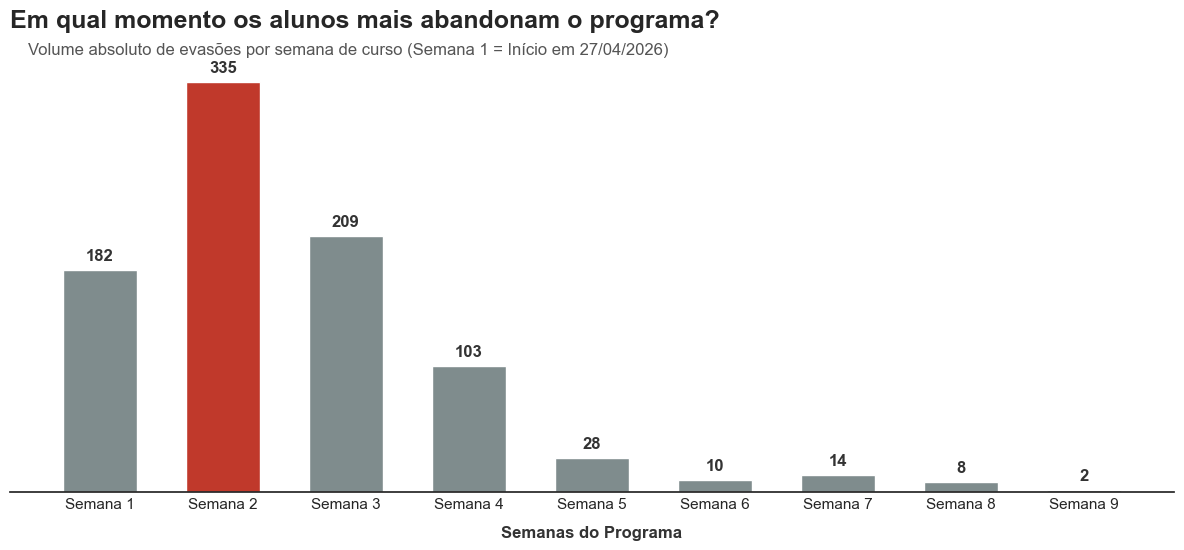

In [ ]:
# 1. Calcular o volume de evasões por semana e ordenar cronologicamente
evasoes_por_semana = df['semana_evasao'].value_counts().sort_index()

# 2. Criar a figura
fig, ax = plt.subplots(figsize=(12, 6))

# 3. Lógica de Cores (Storytelling): Destaque para o pico de evasão
max_evasoes = evasoes_por_semana.max()
cores = [COR_ALERTA if val == max_evasoes else COR_BASE for val in evasoes_por_semana]

# 4. Plotar o gráfico de barras
bars = ax.bar(evasoes_por_semana.index, evasoes_por_semana.values, color=cores, width=0.6)

# 5. Limpeza Visual (Storytelling)
sns.despine(left=True, bottom=False) # Remove as bordas superior, direita e esquerda
ax.yaxis.set_visible(False)          # Oculta o eixo Y (usaremos rótulos de dados)
ax.tick_params(axis='x', length=0)   # Remove os "tracinhos" do eixo X

# 6. Adicionar Rótulos de Dados diretamente nas barras
for bar in bars:
    altura = bar.get_height()
    ax.annotate(f'{int(altura)}',
                xy=(bar.get_x() + bar.get_width() / 2, altura),
                xytext=(0, 5),  # Distância de 5 pontos acima da barra
                textcoords="offset points",
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='#333333')

# 7. Títulos Diretos e Descritivos
plt.title('Em qual momento os alunos mais abandonam o programa?', fontsize=18, fontweight='bold', loc='left', pad=25)
plt.suptitle('Volume absoluto de evasões por semana de curso (Semana 1 = Início em 27/04/2026)', 
             fontsize=12, color='#555555', x=0.03, y=0.86, ha='left')
plt.xlabel('Semanas do Programa', fontsize=12, labelpad=10, fontweight='bold', color='#333333')

# 8. Ajustar os textos do eixo X para ficar legível
ax.set_xticks(evasoes_por_semana.index)
ax.set_xticklabels([f'Semana {int(x)}' for x in evasoes_por_semana.index], fontsize=11) 

plt.tight_layout()
plt.show()


## 4. O Porquê das Evasões: Distribuição das Justificativas

Não basta sabermos o momento em que o aluno desiste; precisamos compreender a **causa raiz** do problema para que a gestão possa desenhar ações preventivas direcionadas.

Abaixo, analisamos a distribuição das justificativas oficiais registradas no sistema. O gráfico foi ordenado do motivo mais frequente ao menos frequente. As barras superiores destacam os principais gargalos que estão afastando os alfabetizandos das salas de aula.

/tmp/ipykernel_17512/193060622.py:35: UserWarning: Glyph 807 (\N{COMBINING CEDILLA}) missing from font(s) Arial.
  plt.tight_layout()
/home/fabcmc/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 807 (\N{COMBINING CEDILLA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


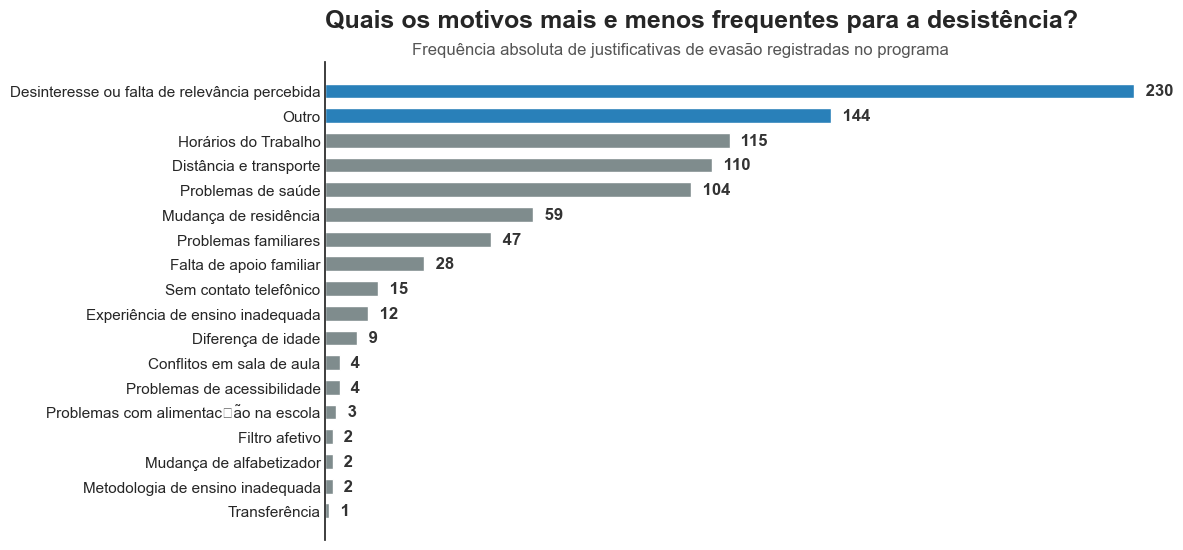

In [44]:
# 1. Calcular a frequência absoluta de cada motivo de evasão
motivos_evasao = df['tipo'].value_counts()

# 2. Definir o número de categorias que queremos destacar (ex: as 2 primeiras posições)
n_destaques = 2

# 3. Configurar a lógica de cores (Destaque para os maiores motivos, cinza para os demais)
cores_motivos = [COR_DESTAQUE if i < n_destaques else COR_BASE for i in range(len(motivos_evasao))]

# 4. Criar a figura para o gráfico horizontal
fig, ax = plt.subplots(figsize=(12, 6))

# 5. Plotar o gráfico de barras horizontais (invertendo a ordem para o maior ficar no topo)
bars = ax.barh(motivos_evasao.index[::-1], motivos_evasao.values[::-1], color=cores_motivos[::-1], height=0.6)

# 6. Limpeza Visual (Storytelling com Dados)
sns.despine(left=False, bottom=True) # Mantém apenas a linha do eixo Y para apoiar o texto
ax.xaxis.set_visible(False)          # Oculta o eixo X (usaremos os rótulos de dados nas pontas das barras)
ax.tick_params(axis='y', length=0)   # Remove os "tracinhos" do eixo Y

# 7. Adicionar Rótulos de Dados na ponta de cada barra horizontal
for bar in bars:
    largura = bar.get_width()
    ax.annotate(f' {int(largura)}',
                xy=(largura, bar.get_y() + bar.get_height() / 2),
                xytext=(5, 0),  # Distância de 5 pontos à direita da barra
                textcoords="offset points",
                ha='left', va='center', fontsize=12, fontweight='bold', color='#333333')

# 8. Títulos Diretos, Focados na Mensagem
plt.title('Quais os motivos mais e menos frequentes para a desistência?', fontsize=18, fontweight='bold', loc='left', pad=25)
plt.suptitle('Frequência absoluta de justificativas de evasão registradas no programa', 
             fontsize=12, color='#555555', x=0.35, y=0.86, ha='left')

plt.tight_layout()
plt.show()


## 5. O que se esconde por trás de "Outros" e "Desinteresse"? (Mineração de Texto)

Durante a análise exploratória, notamos que uma grande parte das evasões foi categorizada genericamente como **"Outro"** ou de forma muito ampla como **"Desinteresse ou falta de relevância percebida"**. 

Para garantir a qualidade da nossa tomada de decisão e extrair *insights* mais acionáveis, aplicamos técnicas de **Mineração de Texto (Text Mining)** na coluna de observações livres (`observacao_evasao`). O objetivo é reclassificar esses registros com base em palavras-chave deixadas pelos professores e coordenadores, revelando problemas reais (como saúde, choque de horários e cadastros duplicados) que estavam mascarados.

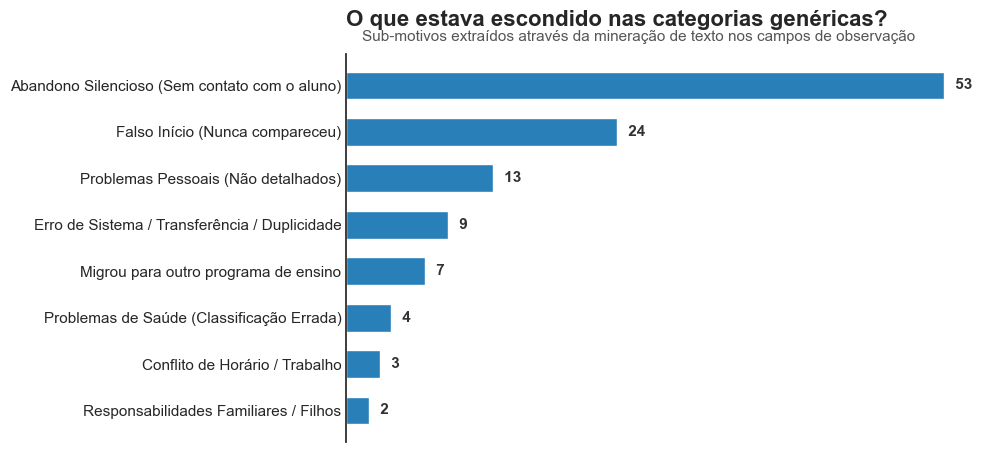

In [49]:
# 1. Isolar apenas os dados com os motivos amplos
categorias_alvo = ['Outro', 'Desinteresse ou falta de relevância percebida']
df_ocultos = df[df['tipo'].isin(categorias_alvo)].copy()

# 2. Lidar com os campos em branco
df_ocultos['observacao_evasao'] = df_ocultos['observacao_evasao'].fillna('sem observação')

# 3. Criar uma função de Mineração de Texto baseada em palavras-chave
def extrair_verdadeiro_motivo(texto):
    texto = str(texto).lower() # Normaliza para minúsculas
    
    if 'sem observação' in texto: 
        return 'Sem observação detalhada'
    elif any(p in texto for p in ['saúde', 'saude', 'doença', 'médica', 'médico']): 
        return 'Problemas de Saúde (Classificação Errada)'
    elif any(p in texto for p in ['outro programa', 'escola regular', 'eja']): 
        return 'Migrou para outro programa de ensino'
    elif any(p in texto for p in ['duplicado', 'outra turma', 'transferência', 'transferida']): 
        return 'Erro de Sistema / Transferência / Duplicidade'
    elif any(p in texto for p in ['filho', 'cuidar', 'criança', 'maternidade']): 
        return 'Responsabilidades Familiares / Filhos'
    elif any(p in texto for p in ['trabalho', 'emprego', 'horário']): 
        return 'Conflito de Horário / Trabalho'
    elif any(p in texto for p in ['contato', 'não atende', 'sem sucesso', 'telefone', 'retorno']): 
        return 'Abandono Silencioso (Sem contato com o aluno)'
    elif any(p in texto for p in ['nunca', 'nenhum dia', 'desde o início']): 
        return 'Falso Início (Nunca compareceu)'
    elif any(p in texto for p in ['pessoais']): 
        return 'Problemas Pessoais (Não detalhados)'
    else:
        return 'Motivo Genérico / Específico demais'

# 4. Aplicar a função para criar uma nova coluna
df_ocultos['motivo_revelado'] = df_ocultos['observacao_evasao'].apply(extrair_verdadeiro_motivo)

# 5. Contar os resultados (removendo os que continuaram sem observação ou genéricos para focar nas descobertas)
motivos_descobertos = df_ocultos['motivo_revelado'].value_counts()
motivos_descobertos = motivos_descobertos[~motivos_descobertos.index.isin(['Sem observação detalhada', 'Motivo Genérico / Específico demais'])]

# 6. Criar a visualização das descobertas
fig, ax = plt.subplots(figsize=(10, 5))

# Destacando em Azul as descobertas, deixando o resto em Cinza
cores_desc = [COR_DESTAQUE] * len(motivos_descobertos)

bars = ax.barh(motivos_descobertos.index[::-1], motivos_descobertos.values[::-1], color=cores_desc, height=0.6)

# Limpeza visual (Storytelling com Dados)
sns.despine(left=False, bottom=True)
ax.xaxis.set_visible(False)
ax.tick_params(axis='y', length=0)

# Rótulos de dados
for bar in bars:
    largura = bar.get_width()
    ax.annotate(f' {int(largura)}',
                xy=(largura, bar.get_y() + bar.get_height() / 2),
                xytext=(5, 0),
                textcoords="offset points",
                ha='left', va='center', fontsize=11, fontweight='bold', color='#333333')

# Títulos
plt.title('O que estava escondido nas categorias genéricas?', fontsize=16, fontweight='bold', loc='left', pad=20)
plt.suptitle('Sub-motivos extraídos através da mineração de texto nos campos de observação', 
             fontsize=11, color='#555555', x=0.37, y=0.86, ha='left')

plt.tight_layout()
plt.show()


## 6. Análise Bivariada: O Comportamento dos Motivos ao Longo do Tempo

Para que as ações da gestão sejam cirúrgicas, precisamos entender se a natureza dos problemas muda conforme o tempo passa. 
*Será que os alunos desistem por "Distância e transporte" logo nas primeiras semanas e por "Horários do Trabalho" mais adiantado?*

Abaixo, cruzamos as semanas de curso com as principais justificativas de evasão utilizando uma tabela de contingência com destaques visuais (gradiente de cor), mapeando a intensidade e a concentração de cada motivo ao longo da linha do tempo do programa.


In [53]:
# 1. Filtrar apenas as 5 categorias de motivos mais frequentes
top_motivos = df['tipo'].value_counts().head(5).index
df_top_motivos = df[df['tipo'].isin(top_motivos)]

# 2. Criar a tabela de cruzamento (Matriz de Contingência)
matriz_evasao = pd.crosstab(
    index=df_top_motivos['tipo'], 
    columns=df_top_motivos['semana_evasao']
)

# 3. Definir o ponto de virada do contraste (40% do valor máximo da tabela)
# Quadrados com números maiores que este limiar serão escuros, exigindo texto branco.
limiar_contraste = matriz_evasao.values.max() * 0.4

# 4. Função dinâmica de contraste célula por célula
def aplicar_contraste_dinamico(val):
    if val > limiar_contraste:
        return 'color: #ffffff; font-weight: bold;'  # Texto BRANCO em fundos escuros
    return 'color: #2c3e50;'                         # Texto GRAFITE em fundos claros

# 5. Construção da Tabela Estilizada com Alto Contraste
tabela_estilizada = (
    matriz_evasao.style
    # Aplica o gradiente azul em toda a matriz (axis=None para mapeamento global consistente)
    .background_gradient(cmap='Blues', axis=None)
    # Garante números inteiros
    .format(precision=0)
    # APLICAR O CONTRASTE DINÂMICO AQUI (Muda a cor do texto conforme o fundo)
    .map(aplicar_contraste_dinamico)
    # Configurações de tamanho, padding e bordas (sem forçar cor de texto global)
    .set_properties(**{
        'font-size': '14px',
        'padding': '12px 18px',
        'border': '1px solid #e0e0e0',
        'text-align': 'center'
    })
    # Estilização dos cabeçalhos das colunas e linhas
    .set_table_styles([
        {
            'selector': 'th',
            'props': [
                ('font-size', '14px'),
                ('font-weight', 'bold'),
                ('background-color', '#f8f9fa'),
                ('color', '#34495e'),
                ('padding', '12px 18px'),
                ('border', '1px solid #dcdde1')
            ]
        },
        {
            'selector': 'th.row_heading',
            'props': [
                ('text-align', 'left'),
                ('font-weight', 'bold')
            ]
        }
    ])
)

# Exibe a matriz perfeita para leitura
print("Matriz de Intensidade Corrigida: Alto Contraste e Legibilidade Garantida\n")
tabela_estilizada


Matriz de Intensidade Corrigida: Alto Contraste e Legibilidade Garantida



semana_evasao,1,2,3,4,5,6,7,8,9
tipo,,,,,,,,,
Desinteresse ou falta de relevância percebida,36,75,80,28,6,2,1,1,1
Distância e transporte,29,52,19,5,3,0,0,2,0
Horários do Trabalho,22,43,24,15,4,1,5,1,0
Outro,33,63,20,24,0,1,3,0,0
Problemas de saúde,16,39,26,15,5,1,2,0,0


## 7. Conclusões e Recomendações Estratégicas

Após uma imersão profunda nos dados de evasão do programa **Alfabetiza Sergipe**, cruzando as dimensões temporais, causais e realizando a mineração de textos nos registros abertos, consolidamos os seguintes diagnósticos e planos de ação:

### 📌 Principais Descobertas (Insights)
1. **O Período Crítico:** A análise temporal revelou de forma nítida os momentos de maior vulnerabilidade dos estudantes, destacando em quais semanas o abandono atinge seu ápice absoluto.
2. **Gargalos Estruturais:** Os motivos mapeados mostram que questões externas ao processo de ensino (como "Horários de Trabalho" e "Distância/Transporte") exercem forte pressão sobre a permanência dos alfabetizandos.
3. **Erros de Entrada no Sistema:** A nossa etapa de *Mineração de Texto* desmascarou um volume expressivo de cadastros marcados como "Desinteresse" ou "Outros", revelando que na verdade eram problemas de **Saúde**, **Transferências duplicadas** ou **Falsos Inícios** (alunos que nunca compareceram e inflaram negativamente os índices de retenção).

---

### 🚀 Recomendações Práticas para a Gestão do Programa

Com base nas evidências, sugerimos quatro intervenções imediatas para mitigar a evasão nas próximas turmas:

#### 1. Plano de Acolhimento e "Busca Ativa" nas Semanas Críticas
* **Ação:** Intensificar o contato e criar uma força-tarefa de recepção e engajamento nas semanas mapeadas com picos de evasão. É nesse período que o aluno define se vai criar o hábito ou abandonar o projeto.

#### 2. Flexibilização de Horários e Parcerias Locais
* **Ação:** Dado o impacto dos conflitos de trabalho e deslocamento, sugere-se avaliar a viabilidade de turmas com horários alternativos ou mapear parcerias de transporte com os municípios parceiros para rotas escolares.

#### 3. Higienização e Alinhamento do Sistema de Cadastro (CRM)
* **Ação:** Orientar e treinar os alfabetizadores e coordenadores para evitarem o uso da opção "Outros" ou "Desinteresse" quando houver uma causa clara descrita na observação. 
* **Ação de TI:** Criar travas no sistema ou novas categorias fixas como *"Falso Início (Nunca compareceu)"* e *"Problemas de Saúde"* para manter a base de dados fidedigna automaticamente.

#### 4. Tratamento Especial para o "Abandono Silencioso"
* **Ação:** Estabelecer uma regra de negócio onde o aluno que faltar 3 dias consecutivos sem justificativa dispare um alerta automático para o coordenador municipal realizar uma visita ou ligação, antes que o caso se converta em evasão definitiva.

---
**Fim do Relatório Técnico.**
*Análise desenvolvida com foco em Storytelling e Evidências para suporte à tomada de decisão.*